In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Imports done ")


Imports done 


In [2]:
url = "https://data.cityofnewyork.us/resource/4b4i-vvec.json"

"""

payment_type = '1' — credit card only. Cash trips always record $0 tip because cash tips aren't tracked digitally.
If you included cash, your averages would be completely wrong.


"""

params = {
    "$select": "tpep_pickup_datetime, tip_amount, fare_amount, trip_distance, passenger_count, payment_type",
    "$where": "payment_type = '1' AND tip_amount > 0 AND tpep_pickup_datetime >= '2023-01-01T00:00:00' AND tpep_pickup_datetime < '2023-02-01T00:00:00'",
    "$limit": 500000,
    "$order": "tpep_pickup_datetime ASC"
}

response = requests.get(url, params=params)
df = pd.DataFrame(response.json())

print(f"Rows retrieved: {len(df)}")
print(df.head())

Rows retrieved: 500000
      tpep_pickup_datetime tip_amount fare_amount trip_distance  \
0  2023-01-01T00:00:09.000       7.44        19.8           3.8   
1  2023-01-01T00:00:13.000       25.0        34.5          8.97   
2  2023-01-01T00:00:18.000        4.9        11.4           2.1   
3  2023-01-01T00:00:47.000        5.0         6.5          0.95   
4  2023-01-01T00:00:57.000        5.0        38.0          9.98   

  passenger_count payment_type  
0             1.0            1  
1             1.0            1  
2             1.0            1  
3             3.0            1  
4             1.0            1  


In [3]:
# Convert datetime first
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

# Fix numeric types
df["tip_amount"] = pd.to_numeric(df["tip_amount"])
df["fare_amount"] = pd.to_numeric(df["fare_amount"])
df["trip_distance"] = pd.to_numeric(df["trip_distance"])
df["passenger_count"] = pd.to_numeric(df["passenger_count"])

# Remove outliers
df = df[df["fare_amount"] >= 2.50]
df = df[df["trip_distance"] > 0]

# Calculate tip percentage
df["tip_pct"] = (df["tip_amount"] / df["fare_amount"]) * 100
df = df[df["tip_pct"] <= 100]

# Extract time features
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["day_of_week"] = df["tpep_pickup_datetime"].dt.day_name()
df["is_late_night"] = df["hour"].between(22, 23) | df["hour"].between(0, 4)
df["date_hour"] = df["tpep_pickup_datetime"].dt.floor("h")

print(f"Clean rows: {len(df)}")
print(df[["tip_amount", "fare_amount", "tip_pct", "hour", "is_late_night"]].describe())

Clean rows: 496304
          tip_amount    fare_amount        tip_pct           hour
count  496304.000000  496304.000000  496304.000000  496304.000000
mean        4.428682      19.077678      25.888755      13.739412
std         3.798598      17.573850       9.625616       5.959819
min         0.010000       3.000000       0.008013       0.000000
25%         2.300000       8.600000      21.287554      10.000000
50%         3.240000      12.800000      26.250000      15.000000
75%         4.950000      20.500000      30.769231      18.000000
max        99.990000     346.000000     100.000000      23.000000


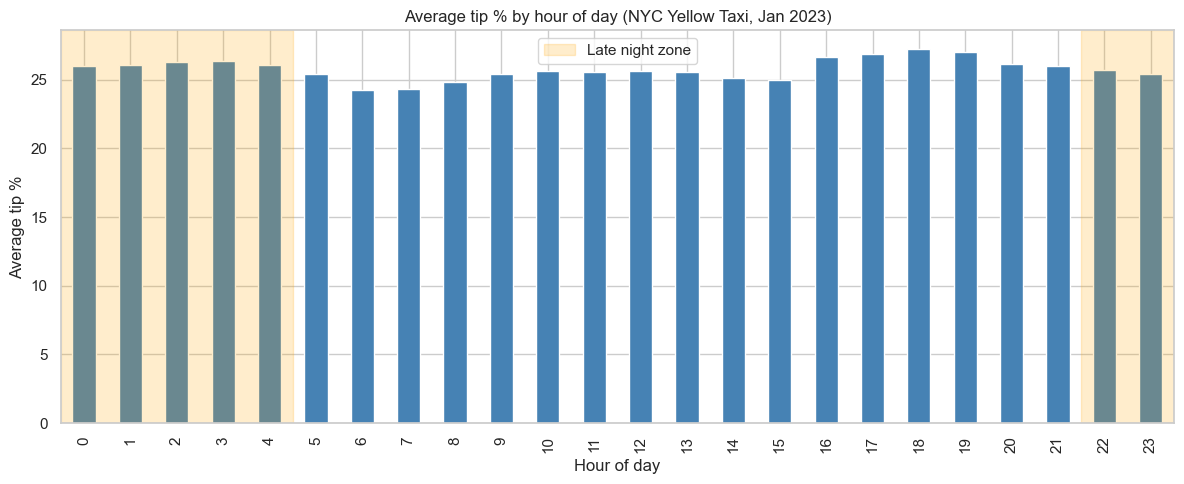

In [4]:
hourly_tips = df.groupby("hour")["tip_pct"].mean()

plt.figure(figsize=(12, 5))
hourly_tips.plot(kind="bar", color="steelblue")
axes = plt.gca()
axes.axvspan(21.5, 23.5, color="orange", alpha=0.2, label="Late night")
axes.axvspan(-0.5, 4.5, color="orange", alpha=0.2)
plt.xlabel("Hour of day")
plt.ylabel("Average tip %")
plt.title("Average tip % by hour of day (NYC Yellow Taxi, Jan 2023)")
plt.legend(["Late night zone"])
plt.tight_layout()
plt.show()

In [5]:
url_weather = "https://archive-api.open-meteo.com/v1/archive"

params_weather = {
    "latitude": 40.7831,
    "longitude": -73.9712,
    "start_date": "2023-01-01",
    "end_date": "2023-01-31",
    "hourly": "temperature_2m,precipitation,rain,snowfall,windspeed_10m,weathercode",
    "timezone": "America/New_York"
}

response_weather = requests.get(url_weather, params=params_weather)
data = response_weather.json()

weather_df = pd.DataFrame({
    "date_hour": pd.to_datetime(data["hourly"]["time"]),
    "temperature": data["hourly"]["temperature_2m"],
    "precipitation": data["hourly"]["precipitation"],
    "rain": data["hourly"]["rain"],
    "snowfall": data["hourly"]["snowfall"],
    "windspeed": data["hourly"]["windspeed_10m"],
    "weathercode": data["hourly"]["weathercode"],
})

print(f"Weather rows: {len(weather_df)}")
print(weather_df.head(10))

Weather rows: 744
            date_hour  temperature  precipitation  rain  snowfall  windspeed  \
0 2023-01-01 00:00:00         10.9            1.1   1.1       0.0       11.7   
1 2023-01-01 01:00:00         10.9            0.9   0.9       0.0        9.1   
2 2023-01-01 02:00:00         10.8            0.1   0.1       0.0       14.4   
3 2023-01-01 03:00:00         10.8            0.0   0.0       0.0       16.6   
4 2023-01-01 04:00:00         10.1            0.0   0.0       0.0       16.9   
5 2023-01-01 05:00:00          9.4            0.0   0.0       0.0       17.2   
6 2023-01-01 06:00:00          8.9            0.0   0.0       0.0       16.9   
7 2023-01-01 07:00:00          8.3            0.0   0.0       0.0       14.9   
8 2023-01-01 08:00:00          8.2            0.0   0.0       0.0       12.3   
9 2023-01-01 09:00:00          8.4            0.0   0.0       0.0       12.6   

   weathercode  
0           55  
1           53  
2           51  
3            0  
4            0  

In [6]:
# Both already datetime, just make sure
df["date_hour"] = pd.to_datetime(df["date_hour"])
weather_df["date_hour"] = pd.to_datetime(weather_df["date_hour"])

# Merge
merged = df.merge(weather_df, on="date_hour", how="left")

# Add flags
merged["bad_weather"] = (merged["precipitation"] > 0) | (merged["snowfall"] > 0)
merged["is_late_night"] = merged["hour"].between(22, 23) | merged["hour"].between(0, 4)

print(f"Merged rows: {len(merged)}")
print(merged[["tpep_pickup_datetime", "tip_pct", "temperature", "precipitation", "bad_weather", "is_late_night"]].head(10))

Merged rows: 496304
  tpep_pickup_datetime    tip_pct  temperature  precipitation  bad_weather  \
0  2023-01-01 00:00:09  37.575758         10.9            1.1         True   
1  2023-01-01 00:00:13  72.463768         10.9            1.1         True   
2  2023-01-01 00:00:18  42.982456         10.9            1.1         True   
3  2023-01-01 00:00:47  76.923077         10.9            1.1         True   
4  2023-01-01 00:00:57  13.157895         10.9            1.1         True   
5  2023-01-01 00:01:07  24.566210         10.9            1.1         True   
6  2023-01-01 00:01:08   0.070423         10.9            1.1         True   
7  2023-01-01 00:01:18  30.896226         10.9            1.1         True   
8  2023-01-01 00:01:21  24.566210         10.9            1.1         True   
9  2023-01-01 00:01:27  22.222222         10.9            1.1         True   

   is_late_night  
0           True  
1           True  
2           True  
3           True  
4           True  
5      

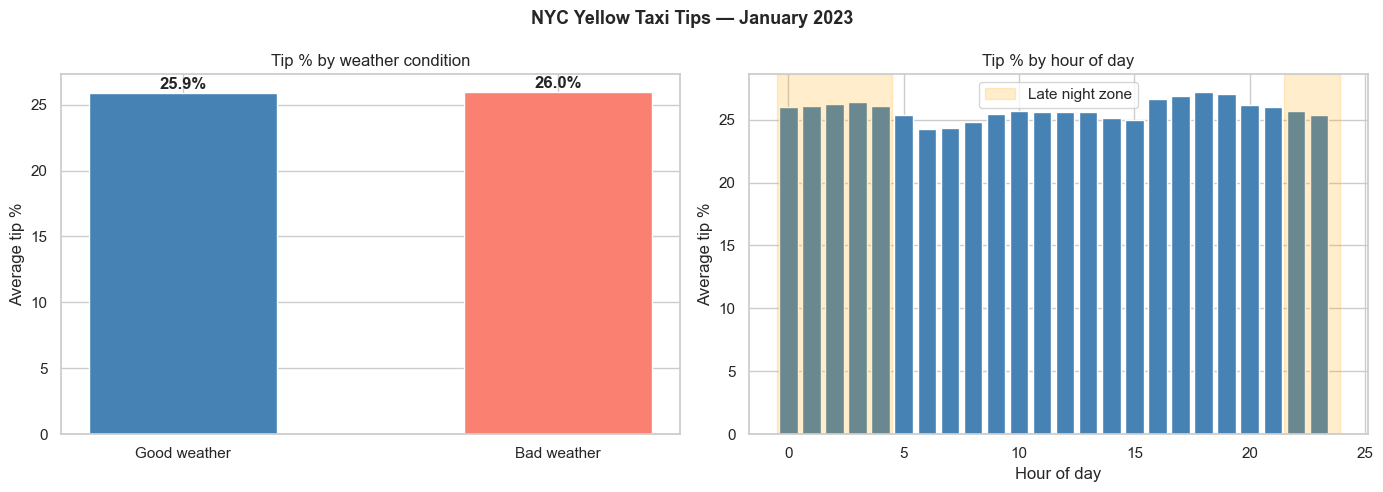


Average tip % by weather:
bad_weather
False    25.86
True     25.99
Name: tip_pct, dtype: float64

Average tip % late night vs normal:
is_late_night
False    25.89
True     25.87
Name: tip_pct, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bad vs good weather
weather_means = merged.groupby("bad_weather")["tip_pct"].mean()
axes[0].bar(["Good weather", "Bad weather"], weather_means.values,
            color=["steelblue", "salmon"], edgecolor="white", width=0.5)
axes[0].set_ylabel("Average tip %")
axes[0].set_title("Tip % by weather condition")
for i, v in enumerate(weather_means.values):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold")

# Plot 2: Tip % by hour of day
hourly = merged.groupby("hour")["tip_pct"].mean()
axes[1].bar(hourly.index, hourly.values, color="steelblue")
axes[1].axvspan(21.5, 23.9, color="orange", alpha=0.2, label="Late night")
axes[1].axvspan(-0.5, 4.5, color="orange", alpha=0.2)
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Average tip %")
axes[1].set_title("Tip % by hour of day")
axes[1].legend(["Late night zone"])

plt.suptitle("NYC Yellow Taxi Tips — January 2023", fontsize=13, fontweight="bold")
plt.tight_layout()
#plt.savefig("/Users/manostsili/Desktop/tip_analysis.png", dpi=150)
plt.show()

# Summary stats
print("\nAverage tip % by weather:")
print(merged.groupby("bad_weather")["tip_pct"].mean().round(2))
print("\nAverage tip % late night vs normal:")
print(merged.groupby("is_late_night")["tip_pct"].mean().round(2))